In [29]:
### POUR SI VOUS FAITES UN TRAINING DU MODEL SUR COLLAB :
# (Pour éviter de devoir import à chaque nouvelle session)
# Sauvegardez les folders nécessaires dans votre drive en amont

from google.colab import drive
drive.mount('/content/drive')
%cd drive/MyDrive/PFE/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Errno 2] No such file or directory: 'drive/MyDrive/PFE/'
/content/drive/MyDrive/PFE


In [30]:
%ls

data/  runs/  thermal.yaml  yolo11n.pt  yolov8n.pt


## 0) Dataset
*Etant donné que le dataset qu'on a déjà est pour modèle YOLO (.JPG et .txt), or nous on veut des masques*

**( à faire tourner si vous n'avez pas le dir masks)**

Redimensionne toutes les images en 640 x 512 :

In [53]:
# from PIL import Image
# import os, sys

# # path = "data/images/train"
# # path = "data/images/val"
# # path = "data/masks/train"
# path = "data/masks/val"

# dirs = os.listdir( path )

# SIZE = (640, 512)
# for filename in dirs:
#     if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
#         continue

#     file_path = os.path.join(path, filename)
#     try:
#         with Image.open(file_path) as im:
#             if im.size != SIZE:
#                 im = im.convert("L")  # grayscale thermique
#                 im_resized = im.resize(SIZE, Image.BILINEAR)
#                 im_resized.save(file_path)
#     except Exception as e:
#         print(f"Erreur avec {file_path}: {e}")

Génère les .png des masks :

In [31]:
# import os
# import cv2
# import numpy as np
# from tqdm import tqdm

# IMG_DIR = "data/images/train"
# LBL_DIR = "data/labels/train"
# OUT_MASK_DIR = "data/masks/train"
# # IMG_DIR = "data/images/val"
# # LBL_DIR = "data/labels/val"
# # OUT_MASK_DIR = "data/masks/val"

# os.makedirs(OUT_MASK_DIR, exist_ok=True)

# for img_name in tqdm(os.listdir(IMG_DIR)):
#     if not img_name.lower().endswith(".jpg"):
#         continue

#     img_path = os.path.join(IMG_DIR, img_name)
#     label_path = os.path.join(
#         LBL_DIR, os.path.splitext(img_name)[0] + ".txt"
#     )

#     image = cv2.imread(img_path)
#     if image is None:
#         continue

#     h, w, _ = image.shape
#     mask = np.zeros((h, w), dtype=np.uint8)

#     if os.path.exists(label_path):
#         with open(label_path, "r") as f:
#             for line in f:
#                 cls, xc, yc, bw, bh = map(float, line.split())

#                 x1 = int((xc - bw / 2) * w)
#                 y1 = int((yc - bh / 2) * h)
#                 x2 = int((xc + bw / 2) * w)
#                 y2 = int((yc + bh / 2) * h)

#                 # Clamp
#                 x1, y1 = max(0, x1), max(0, y1)
#                 x2, y2 = min(w - 1, x2), min(h - 1, y2)

#                 mask[y1:y2, x1:x2] = 255

#     out_path = os.path.join(
#         OUT_MASK_DIR, os.path.splitext(img_name)[0] + ".png"
#     )
#     cv2.imwrite(out_path, mask)

## 1) U-NET se rapprochant de Attention U-NET d'Oktay

In [32]:
!pip install segmentation_models_pytorch

In [33]:
!pip install albumentations opencv-python

In [34]:
!pip install tqdm

In [35]:
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset
from PIL import Image

In [36]:
# Pas la version d’Oktay, mais y ressemble (donc plus simple à test)
model = smp.Unet(
    encoder_name="resnet34", # ResNet backbone, "resnet18" est + léger
    encoder_weights=None, # "imagenet" = pretrained weights
    in_channels=1,
    classes=1,
    # activation='sigmoid',
    decoder_attention_type='scse' #  attention module used in decoder of the model - One of [None, scse]
)

In [54]:
class ThermalSegDataset(Dataset):
    def __init__(self, images_dir, masks_dir, augmentations=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.images = sorted(os.listdir(images_dir))
        self.augmentations = augmentations

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(
            self.masks_dir,
            os.path.splitext(img_name)[0] + ".png"
        )
        # print(f"img_name : {img_name}")
        # print(f"img_path : {img_path}")
        # print(f"mask_path : {mask_path}")

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            print("----- images non lues/trouvées")
        if mask is None:
            print("----- masques non lues/trouvées")

        image = image.astype(np.float32) / 255.0
        mask = (mask > 127).astype(np.float32)

        image = np.expand_dims(image, axis=2)
        mask = np.expand_dims(mask, axis=2)

        if self.augmentations:
            augmented = self.augmentations(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        image = torch.from_numpy(image).permute(2, 0, 1)
        mask = torch.from_numpy(mask).permute(2, 0, 1)

        return image, mask


#### Data augmentation :

In [38]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=5, p=0.5),
    # A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),

    # A.RandomResizedCrop(256, 256, scale=(0.8, 1.0)),
    # A.RandomBrightnessContrast(p=0.2),
    # A.GridDistortion(p=0.2),
    # A.ElasticTransform(p=0.2),
    # A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    # ToTensorV2(),
 ]) #, additional_targets={'mask': 'mask'})

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


#### Loss :

In [39]:
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss  = smp.losses.SoftBCEWithLogitsLoss()
focal_loss = smp.losses.FocalLoss(mode="binary", gamma=2.0)

def loss_fn(pred, target):
    return dice_loss(pred, target) + bce_loss(pred, target)
    # return dice_loss(pred, target) + bce_loss(pred, target) + 0.5 * focal_loss(pred, target)

# Focal Loss : bon si bcp de faux positifs, petites cibles, mais long
# Ou : (va prendre 53438 ans mais très robuste)
# loss_fn = Dice + BCE + 0.5* focal loss

#### Metriques :

In [40]:
def dice_coefficient(outputs, targets, threshold=0.5):
    outputs = (outputs > threshold).float()
    intersection = (outputs * targets.float()).sum()
    dice = (2 * intersection) / (outputs.sum() + targets.sum())
    return dice.item()

def iou_score(outputs, targets, threshold=0.5):
    outputs = (outputs > threshold).float()
    intersection = (outputs * targets.float()).sum()
    union = outputs.sum() + targets.sum() - intersection
    iou = intersection / union
    return iou.item()

def f1_score(outputs, target, threshold=0.5):
    outputs = (outputs > threshold).float()
    target = target.float()

    tp = (outputs * target).sum()
    fp = (outputs * (1 - target)).sum()
    fn = ((1 - outputs) * target).sum()
    return (2 * tp) / (2 * tp + fp + fn)

def recall_score(outputs, target, threshold=0.5):
    outputs = (outputs > threshold).float()
    target = target.float()

    tp = (outputs * target).sum()
    fn = ((1 - outputs) * target).sum()
    return tp / (tp + fn)

def precision_score(outputs, target, threshold=0.5):
    outputs = (outputs > threshold).float()
    target = target.float()

    tp = (outputs * target).sum()
    fp = (outputs * (1 - target)).sum()
    return tp / (tp + fp)

#### Training :

In [55]:
nb_epochs = 20
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
# scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-2, steps_per_epoch=len(train_loader), epochs=nb_epochs)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [56]:
from torch.utils.data import DataLoader

train_ds = ThermalSegDataset(
    images_dir="data/images/train",
    masks_dir="data/masks/train",
    # augmentations=train_aug
)

val_ds = ThermalSegDataset(
    images_dir="data/images/val",
    masks_dir="data/masks/val"
)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8)

In [57]:
model.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [58]:
from tqdm import tqdm

for epoch in range(nb_epochs):
    model.train()
    train_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{nb_epochs}", leave=False)

    for x, y in pbar:
        x, y = x.to(device), y.to(device)

        pred = model(x)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    avg_loss = train_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{nb_epochs} - Train Loss: {avg_loss:.4f}")

Epoch 1/20 - Train Loss: 0.8556


Epoch 2/20 - Train Loss: 0.4624


Epoch 3/20 - Train Loss: 0.4139


Epoch 4/20 - Train Loss: 0.3769


Epoch 5/20 - Train Loss: 0.3663


...

Epoch 16/20 - Train Loss: 0.2670


Epoch 17/20 - Train Loss: 0.2455


Epoch 18/20 - Train Loss: 0.2426


Epoch 19/20 - Train Loss: 0.2380


Epoch 20/20 - Train Loss: 0.2307


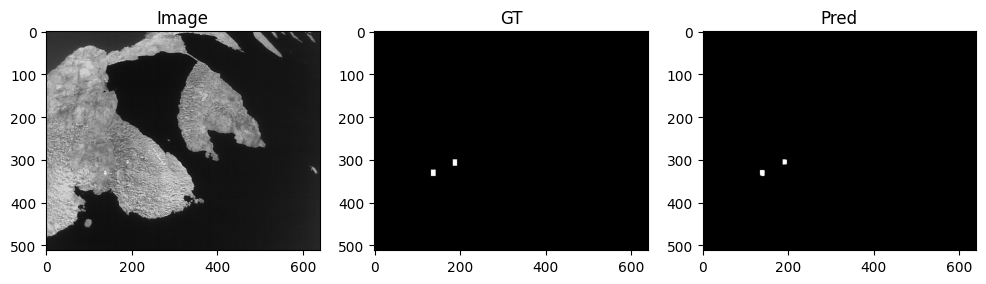

In [60]:
import matplotlib.pyplot as plt

model.eval()

x, y = next(iter(val_loader))
x = x.to(device)
with torch.no_grad():
    pred = torch.sigmoid(model(x))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(x[0,0].cpu(), cmap="gray")

plt.subplot(1,3,2)
plt.title("GT")
plt.imshow(y[0,0], cmap="gray")

plt.subplot(1,3,3)
plt.title("Pred")
plt.imshow(pred[0,0].cpu(), cmap="gray")

plt.show()

#### Sauvegarde ONNX (pour la télécommande) :

## 2) Vraiment Attention U-nET


In [ ]:
import torch
import torch.nn as nn

# Block de convolution (double conv)
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

# Attention Gate
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.psi(torch.relu(g1 + x1))
        return x * psi

# Attention U-Net
class AttentionUNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()
        # encoder
        self.conv1 = ConvBlock(n_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # decoder
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.att2 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.conv_up2 = ConvBlock(128, 64)

        self.final = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        enc1 = self.conv1(x)
        enc2 = self.conv2(self.pool1(enc1))

        dec2_up = self.up2(enc2)
        # Attention gating
        enc1_att = self.att2(g=dec2_up, x=enc1)
        # concat
        cat2 = torch.cat([dec2_up, enc1_att], dim=1)
        dec2 = self.conv_up2(cat2)

        return self.final(dec2)
